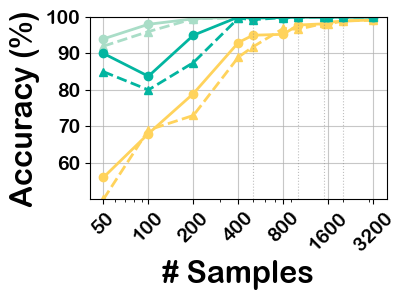

Saved: subset_size_results.csv, dekait_subset_scaling.pdf


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


plt.rcParams['font.family'] = 'Arial Rounded MT Bold'


BASE_DIR = r"..."


SUBSET_SIZES = [50, 100, 200, 400, 500, 800, 1000, 1500, 1600, 2000, 3200]
DATASETS = ["reg", "tor", "vpn"]
MODELS = ["dekait_tiny_checkpoints", "dekait_small_checkpoints"]
MODEL_LABELS = {
    "dekait_tiny_checkpoints": "De-KAiT-Tiny",
    "dekait_small_checkpoints": "De-KAiT-Small"
}


records = []


for size in SUBSET_SIZES:
    for dataset in DATASETS:
        for model_dir in MODELS:
            csv_path = os.path.join(BASE_DIR, str(size), dataset, model_dir, "dekait_history.csv")
            if not os.path.isfile(csv_path):
                continue
            df = pd.read_csv(csv_path)
            best_row = df.loc[df["val_f1"].idxmax()]
            records.append({
                "subset_size": size,
                "dataset": dataset.upper(),
                "model": MODEL_LABELS[model_dir],
                "val_acc": best_row["val_acc"] * 100,
            })


results = pd.DataFrame(records)
results.to_csv("subset_size_results.csv", index=False)


colors = {
    "REG": "#FFD35C",
    "TOR": "#A9DDC7",
    "VPN": "#02B5A0",
}
linestyles = {"De-KAiT-Tiny": "--", "De-KAiT-Small": "-"}
markers    = {"De-KAiT-Tiny": "^", "De-KAiT-Small": "o"}
dataset_labels = {"REG": "Regular flow", "TOR": "Tor flow", "VPN": "VPN flow"}


shown_ticks = [50, 100, 200, 400, 800, 1600, 3200]
hidden_ticks = [t for t in SUBSET_SIZES if t not in shown_ticks]


fig = plt.figure(figsize=(4.15, 3.1))
ax = fig.add_subplot(111)


for dataset in ["REG", "TOR", "VPN"]:
    for model in ["De-KAiT-Tiny", "De-KAiT-Small"]:
        sub = results[(results["dataset"] == dataset) & (results["model"] == model)].sort_values("subset_size")
        if sub.empty:
            continue
        ax.plot(
            sub["subset_size"],
            sub["val_acc"],
            label=f"{dataset_labels[dataset]} ({model})",
            color=colors[dataset],
            linestyle=linestyles[model],
            marker=markers[model],
            linewidth=2
        )


for x in hidden_ticks:
    ax.axvline(x, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)


ax.set_xlabel("# Samples", fontweight='bold', fontsize=22)
ax.set_ylabel("Accuracy (%)", fontweight='bold', fontsize=22)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks(shown_ticks)
ax.tick_params(axis="x", rotation=45, labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylim(50, 100)
ax.set_yticks([60, 70, 80, 90, 100])
ax.grid(alpha=0.7)


# plt.legend(fontsize=18, loc='lower right')
plt.tight_layout()
plt.savefig("dekait_subset_scaling.pdf", format="pdf", bbox_inches='tight')
plt.show()


print("Saved: subset_size_results.csv, dekait_subset_scaling.pdf")

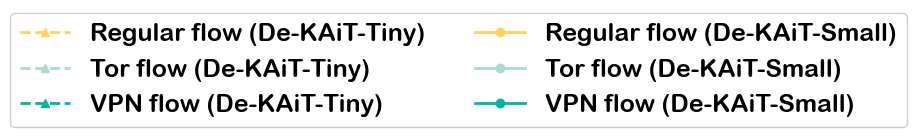

Saved: dekait_legend.pdf


In [2]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


plt.rcParams['font.family'] = 'Arial Rounded MT Bold'


colors = {"REG": "#FFD35C", "TOR": "#A9DDC7", "VPN": "#02B5A0"}
linestyles = {"De-KAiT-Tiny": "--", "De-KAiT-Small": "-"}
markers    = {"De-KAiT-Tiny": "^", "De-KAiT-Small": "o"}
dataset_labels = {"REG": "Regular flow", "TOR": "Tor flow", "VPN": "VPN flow"}


handles = []
for model in ["De-KAiT-Tiny", "De-KAiT-Small"]:
    for dataset in ["REG", "TOR", "VPN"]:
        handle = mlines.Line2D(
            [], [],
            color=colors[dataset],
            linestyle=linestyles[model],
            marker=markers[model],
            linewidth=2,
            label=f"{dataset_labels[dataset]} ({model})"
        )
        handles.append(handle)


fig, ax = plt.subplots(figsize=(9.3, 1.5))
ax.axis("off")


ax.legend(
    handles=handles,
    fontsize=18,
    loc="center",
    frameon=True,
    framealpha=1.0,
    ncol=2
)


plt.tight_layout()
plt.savefig("dekait_legend.pdf", format="pdf", bbox_inches="tight")
plt.show()


print("Saved: dekait_legend.pdf")